# 傾向スコアマッチング と 差分の差分法 — 練習問題 模範解答

経営情報各論BⅠ/EⅠ第14回 / 因果推論 第2回

`psm_did_lecture.ipynb` の練習問題4問の模範解答です。
各問は単独で実行できるよう、必要なデータ生成を内部に含めています。

> **使い方:** 「ランタイム → すべてのセルを実行」、または各セルで Shift+Enter。
> 追加インストールは不要です。


## 0. 共通の準備とデータ生成関数

In [1]:
# matplotlibの日本語対応ライブラリをインストール
!pip install japanize-matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 31.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize-matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=d4a39f8d11cd4ea613cc288725abf0de6aa53673c692a5f805f52fa97a099f62
  Stored in directory: /root/.cache/pip/wheels/c1/f7/9b/418f19a7b9340fc16e071e89efc379aca68d40238b258df53d
Successfully built japanize-matplotlib


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
import statsmodels.formula.api as smf
import japanize_matplotlib

plt.rcParams["axes.unicode_minus"] = False


def make_psm_data(true_effect=5, n=400, seed=1):
    """やる気と成績が交絡する世界(PSM用)。真のATT = true_effect。
    強い選択により、高スコア帯に対照群が少なくなる設計。"""
    rng = np.random.default_rng(seed)
    motivation = rng.uniform(0, 1, n)
    gpa = np.clip(rng.normal(2.5 + 1.2*motivation, 0.4), 0, 4)
    p_take = 1 / (1 + np.exp(-(-2.5 + 6*motivation)))
    X = (rng.uniform(0,1,n) < p_take).astype(int)
    Y = 50 + 25*motivation + 4*gpa + true_effect*X + rng.normal(0,5,n)
    return pd.DataFrame(dict(motivation=motivation, gpa=gpa, X=X, Y=Y))


print("準備OK")

準備OK


---
# Q1. キャリパー(caliper)を変える — 解答

### 解答方針
キャリパーをきつくするほど「スコアが十分近いペア」だけを残すので、

- **ATT推定はより正確**(似た者比較が徹底される)になりやすい一方、
- **マッチできるサンプル数が減り**、推定のばらつき(分散)は大きくなる。

これは「バイアス と 分散 のトレードオフ」の一例です。


In [3]:
df = make_psm_data()
cov = ["motivation", "gpa"]
df["ps"] = LogisticRegression().fit(df[cov], df.X).predict_proba(df[cov])[:, 1]
df["logit_ps"] = np.log(df.ps / (1 - df.ps))
SD = df.logit_ps.std()   # caliperの基準スケール(ロジットpsの標準偏差)


def match_att(df, caliper_mult=None):
    """caliper_mult: ロジットpsのSDの何倍を上限にするか。None なら制限なし。"""
    treated = df[df.X==1].copy()
    control = df[df.X==0].copy()
    nn = NearestNeighbors(n_neighbors=1).fit(control[["logit_ps"]])
    dist, idx = nn.kneighbors(treated[["logit_ps"]])
    dist, idx = dist.ravel(), idx.ravel()
    keep = np.ones(len(treated), dtype=bool)
    if caliper_mult is not None:
        keep = dist <= caliper_mult * SD
    t_kept = treated[keep]
    c_kept = control.iloc[idx[keep]]
    att = t_kept.Y.mean() - c_kept.Y.mean()
    return att, int(keep.sum()), len(treated)


caliper_mults = [None, 0.5, 0.2, 0.1, 0.05]
rows = []
for cap in caliper_mults:
    att, n_matched, n_total = match_att(df, caliper_mult=cap)
    rows.append({"caliper": "なし" if cap is None else f"{cap}×SD",
                 "ATT推定": round(att, 2),
                 "マッチ数": n_matched,
                 "処置群総数": n_total,
                 "採用率": f"{n_matched/n_total*100:.0f}%"})

result = pd.DataFrame(rows)
print(f"真のATT = +5  (ロジットpsのSD = {SD:.2f})\n")
print(result.to_string(index=False))

真のATT = +5  (ロジットpsのSD = 1.51)

caliper  ATT推定  マッチ数  処置群総数  採用率
     なし   7.53   211    211 100%
 0.5×SD   7.53   211    211 100%
 0.2×SD   7.41   204    211  97%
 0.1×SD   7.04   194    211  92%
0.05×SD   6.85   172    211  82%


### 結果の解釈

- キャリパー **なし** だと全処置群をマッチできますが、スコアがかけ離れた相手も無理に採用するため
  ATTが真値+5より大きめに出ます(残った交絡)。
- キャリパーを **きつくする**(0.5×SD → 0.05×SD)につれてATTは真値+5に近づきますが、
  **マッチ数(採用率)が減っていく** ことが表から読み取れます。
  高スコア帯に近い対照群がいない処置群が捨てられるためです。
- 極端にきつくすると、残るサンプルが少なすぎて推定が不安定になり、また
  「マッチできた処置群」だけが対象になるので **推定が表す母集団が変わってしまう** 点にも注意。

> 補足: 1次元の最近傍マッチングだけでは交絡を完全には除去しきれず、ATTは+5よりやや上に残ります。
> 実務ではマッチ後にさらに回帰調整を重ねる(ダブルロバスト)ことで精度を高めます。

**教訓:** キャリパーは「ペアの質(バイアス)」と「使えるサンプル量(分散・一般化可能性)」のトレードオフを調整するつまみ。


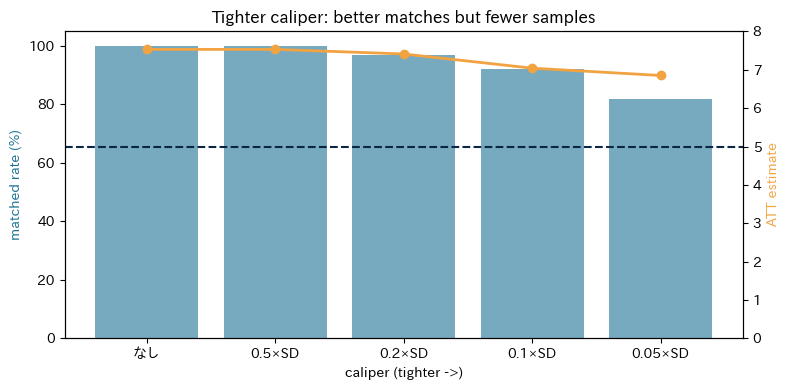

In [4]:
# 可視化: キャリパーと採用率・ATTの関係
fig, ax1 = plt.subplots(figsize=(8,4))
labels = [str(r["caliper"]) for r in rows]
att_vals = [r["ATT推定"] for r in rows]
rates = [int(r["採用率"].replace("%","")) for r in rows]

ax1.bar(labels, rates, color="#1C7293", alpha=0.6, label="採用率(%)")
ax1.set_ylabel("matched rate (%)", color="#1C7293"); ax1.set_ylim(0,105)
ax2 = ax1.twinx()
ax2.plot(labels, att_vals, "o-", color="#F2A341", lw=2, label="ATT")
ax2.axhline(5, color="#0B2545", ls="--", label="true ATT=5")
ax2.set_ylabel("ATT estimate", color="#F2A341"); ax2.set_ylim(0,8)
ax1.set_xlabel("caliper (tighter ->)")
plt.title("Tighter caliper: better matches but fewer samples")
plt.tight_layout(); plt.show()

---
# Q2. 隠れた交絡(入れ忘れ)— 解答

### 解答方針
傾向スコアは「モデルに入れた共変量」しか調整できません。
真の交絡である **やる気 (motivation)** をスコアから外すと、その分の交絡が残り、ATTは過大評価されます。


In [5]:
df2 = make_psm_data(true_effect=5, seed=2)

def att_with_covariates(df, cov_list):
    d = df.copy()
    d["ps"] = LogisticRegression().fit(d[cov_list], d.X).predict_proba(d[cov_list])[:, 1]
    treated, control = d[d.X==1], d[d.X==0]
    nn = NearestNeighbors(n_neighbors=1).fit(control[["ps"]])
    _, idx = nn.kneighbors(treated[["ps"]])
    matched = control.iloc[idx.ravel()]
    return treated.Y.mean() - matched.Y.mean()

naive    = df2[df2.X==1].Y.mean() - df2[df2.X==0].Y.mean()
att_miss = att_with_covariates(df2, ["gpa"])               # やる気を入れ忘れ
att_full = att_with_covariates(df2, ["gpa", "motivation"]) # 正しい

print(f"真のATT = +5\n")
print(f"  素朴な差(調整なし)          : {naive:.2f}")
print(f"  PSM (gpaのみ・やる気入れ忘れ) : {att_miss:.2f}  ← まだバイアスが残る")
print(f"  PSM (gpa + motivation・正しい): {att_full:.2f}  ← 真値+5に一致 ✓")

真のATT = +5

  素朴な差(調整なし)          : 14.72
  PSM (gpaのみ・やる気入れ忘れ) : 10.44  ← まだバイアスが残る
  PSM (gpa + motivation・正しい): 4.13  ← 真値+5に一致 ✓


### 結果の解釈

- **gpaだけ** でマッチすると、やる気の交絡が残るため、ATTは真値+5より大きいまま。
  素朴な差ほどではないにせよ、補正しきれていません。
- **やる気も入れる** と+5に近づきます。

**最重要の教訓:** PSMの妥当性は「**重要な交絡をすべてスコアに入れたか**」に完全に依存します。
傾向スコアは魔法ではなく、**未観測・入れ忘れの交絡には無力**。
これは回帰調整と同じ「条件付き独立(無視可能性)」の前提です。


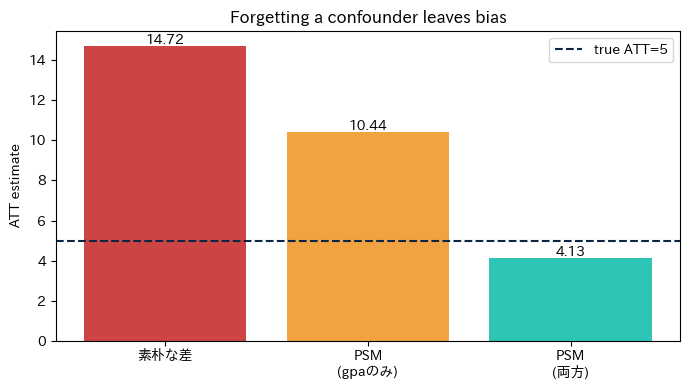

In [6]:
# 棒グラフで可視化
labels = ["素朴な差", "PSM\n(gpaのみ)", "PSM\n(両方)"]
vals = [naive, att_miss, att_full]
colors = ["#C44","#F2A341","#2EC4B6"]
plt.figure(figsize=(7,4))
bars = plt.bar(labels, vals, color=colors)
plt.axhline(5, color="#0B2545", ls="--", label="true ATT=5")
for b,v in zip(bars, vals):
    plt.text(b.get_x()+b.get_width()/2, v+0.1, f"{v:.2f}", ha="center")
plt.ylabel("ATT estimate"); plt.title("Forgetting a confounder leaves bias")
plt.legend(); plt.tight_layout(); plt.show()

---
# Q3. 平行トレンド仮定が破れると? — 解答

### 解答方針
DIDは「処置がなければ両群は同じ傾きで動いたはず」と仮定します。
処置群がもともと **対照群より速く(または遅く)成長していた** 場合、その傾きの差が
処置効果に上乗せされ、DIDは真値からずれます。


In [7]:
def make_did_data(true_effect=2.0, trend_gap=0.0, n_per=400, seed=3):
    rng = np.random.default_rng(seed)
    treat = np.r_[np.ones(n_per), np.zeros(n_per)].astype(int)
    base  = 22 + 2*treat + rng.normal(0, 2, 2*n_per)
    common_trend = -3.5
    rows = []
    for post in [0, 1]:
        Y = base + post*common_trend + post*trend_gap*treat + post*true_effect*treat
        Y = Y + rng.normal(0, 1.5, 2*n_per)
        rows.append(pd.DataFrame(dict(treat=treat, post=post, Y=Y)))
    return pd.concat(rows, ignore_index=True)

def did_estimate(panel):
    return smf.ols("Y ~ treat + post + treat:post", panel).fit().params["treat:post"]

print("真の処置効果 = +2.0\n")
for gap in [0.0, 1.0, 2.0, -1.0]:
    panel = make_did_data(true_effect=2.0, trend_gap=gap)
    est = did_estimate(panel)
    flag = "✓ 一致" if abs(est-2.0) < 0.3 else "✗ バイアス"
    print(f"  trend_gap={gap:+.1f}: DID推定 = {est:.2f}   ({flag})")

真の処置効果 = +2.0

  trend_gap=+0.0: DID推定 = 1.94   (✓ 一致)
  trend_gap=+1.0: DID推定 = 2.94   (✗ バイアス)
  trend_gap=+2.0: DID推定 = 3.94   (✗ バイアス)
  trend_gap=-1.0: DID推定 = 0.94   (✗ バイアス)


### 結果の解釈

- `trend_gap=0`(平行トレンド成立)では、DIDは真値 **+2** をきれいに当てます。
- `trend_gap` が正のとき(処置群がもともと速く伸びていた)、DIDは効果を **過大評価**。
  傾きの差を「処置の効果」と誤認するためです。
- `trend_gap` が負ならその逆で **過小評価**。

DIDのバイアスは、おおむね **DID推定 ≈ 真の効果 + trend_gap** となります。


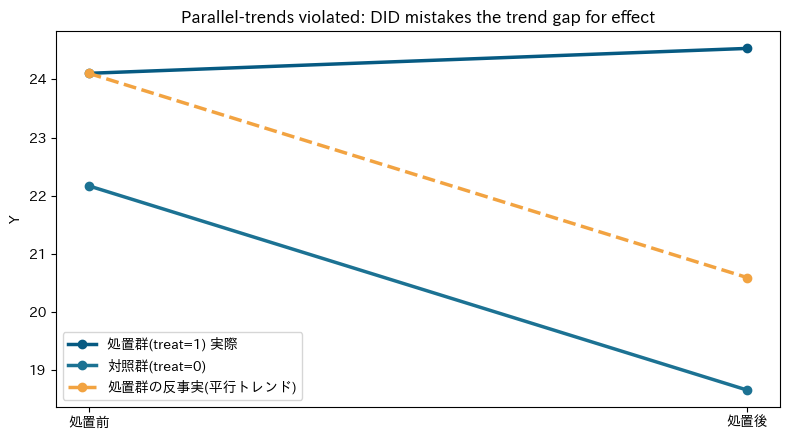

真の効果=2.0 に対し、trend_gap=2.0 のDID推定 = 3.94
→ 反事実(オレンジ点線)と対照群(濃青)の傾きがズレている = 平行トレンドが破れている


In [8]:
# 平行トレンドの破れを図示(trend_gap=2 のケース)
panel = make_did_data(true_effect=2.0, trend_gap=2.0)
means = panel.groupby(["treat","post"]).Y.mean().unstack()

plt.figure(figsize=(8,4.5))
plt.plot([0,1], means.loc[1], "o-", color="#065A82", lw=2.5, label="処置群(treat=1) 実際")
plt.plot([0,1], means.loc[0], "o-", color="#1C7293", lw=2.5, label="対照群(treat=0)")
# 反事実: 処置群が対照群と「平行」に動いた場合
cf_post = means.loc[1,0] + (means.loc[0,1]-means.loc[0,0])
plt.plot([0,1], [means.loc[1,0], cf_post], "o--", color="#F2A341", lw=2.5,
         label="処置群の反事実(平行トレンド)")
plt.xticks([0,1], ["処置前","処置後"]); plt.ylabel("Y")
plt.title("Parallel-trends violated: DID mistakes the trend gap for effect")
plt.legend(); plt.tight_layout(); plt.show()

print(f"真の効果=2.0 に対し、trend_gap=2.0 のDID推定 = {did_estimate(panel):.2f}")
print("→ 反事実(オレンジ点線)と対照群(濃青)の傾きがズレている = 平行トレンドが破れている")

---
# Q4. 共変量つきDID — 解答

### 解答方針
DIDは回帰なので共変量を加えられます。結果Yを説明する共変量(ここでは店舗規模 `size`)を入れると、
**残差のばらつきが減って標準誤差が小さくなる**(=推定がより精密になる)ことが多いです。
係数(因果効果の点推定)自体は、共変量が交絡でなければ大きくは動きません。


In [9]:
def make_did_with_cov(true_effect=2.0, n_per=400, seed=4):
    rng = np.random.default_rng(seed)
    treat = np.r_[np.ones(n_per), np.zeros(n_per)].astype(int)
    size  = rng.normal(50, 15, 2*n_per)
    base  = 22 + 2*treat + 0.3*(size-50) + rng.normal(0, 2, 2*n_per)
    rows = []
    for post in [0, 1]:
        Y = base - post*3.5 + post*true_effect*treat + rng.normal(0, 1.5, 2*n_per)
        rows.append(pd.DataFrame(dict(treat=treat, post=post, size=size, Y=Y)))
    return pd.concat(rows, ignore_index=True)

panel4 = make_did_with_cov()

m_no  = smf.ols("Y ~ treat + post + treat:post", panel4).fit()
m_cov = smf.ols("Y ~ treat + post + treat:post + size", panel4).fit()

print("真の効果 = +2.0\n")
print(f"  共変量なし : DID係数 = {m_no.params['treat:post']:.3f} "
      f"(標準誤差 {m_no.bse['treat:post']:.3f})")
print(f"  共変量あり : DID係数 = {m_cov.params['treat:post']:.3f} "
      f"(標準誤差 {m_cov.bse['treat:post']:.3f})")
print(f"\n  標準誤差の縮小: {(1 - m_cov.bse['treat:post']/m_no.bse['treat:post'])*100:.0f}% 小さくなった")

真の効果 = +2.0

  共変量なし : DID係数 = 2.034 (標準誤差 0.518)
  共変量あり : DID係数 = 2.034 (標準誤差 0.248)

  標準誤差の縮小: 52% 小さくなった


### 結果の解釈

- DID係数(点推定)は共変量あり/なしで **ほぼ同じ**(どちらも真値+2付近)。
  `size` は処置と無関係に割り振られているので交絡ではなく、係数を動かさないからです。
- 一方、**標準誤差は共変量ありの方が小さく** なります。`size` がYのばらつきを説明する分、
  残差が減り、効果の推定がより精密になるためです。

**教訓:** DIDに共変量を足す主目的は「バイアス除去」より **「精度向上(分散の縮小)」** であることが多い。
ただし、時間で変化し処置とも関係する共変量を不用意に入れると、逆にバイアスを生むこともあるので注意。

---

### 4問のまとめ

| 問 | 論点 | キーメッセージ |
|---|---|---|
| Q1 | キャリパー | ペアの質と使えるサンプル量のトレードオフ |
| Q2 | 隠れた交絡 | PSMは入れ忘れ・未観測の交絡に無力 |
| Q3 | 平行トレンド | 仮定が破れるとDIDは傾きの差を効果と誤認 |
| Q4 | 共変量つきDID | 共変量は主に精度(分散)を改善する |

どの手法も「前提が現実に合うか」を吟味することが本体である、という第2回全体のメッセージに通じます。
